# ANFIS para Diagnóstico de Câncer de Mama — WDBC

**Disciplina:** ELE075 — Sistemas Nebulosos (UFMG / DEE)  
**Trabalho Final Computacional — ANFIS**  
**Prof. Cristiano Leite de Castro**

---

## Objetivo

Replicar os experimentos de classificação baseados em ANFIS descritos nos dois artigos de referência:

| # | Artigo | Dataset | Melhor resultado |
|---|--------|---------|------------------|
| 1 | Khan et al. (2020, IEEE ICCWAMTIP) — *"Breast Cancer Diagnosis using Digitized Images of FNA Breast Biopsy and Optimized Neurofuzzy System"* | WDBC | AR + CBOA-ANFIS → **99,29%** |
| 2 | Zarbakhsh et al. (2017, CICN) — *"Early detection of breast cancer using optimized ANFIS and features selection"* | WBCD (adaptado para WDBC) | COA-AR-ANFIS → **99,26%** |

### Três experimentos progressivos

1. **Baseline** — ANFIS em todas as 30 features (sem seleção) → espelha 96,84% (Art.1) e 96,57% (Art.2)
2. **Feature selection** — redução de features por correlação + ANOVA → espelha 98,24% (Art.1) e 98,25% (Art.2)
3. **Otimizado** — busca em grade (num_rules × mf_type) + CV 5-fold → espelha 99,29% (Art.1) e 99,26% (Art.2)

### Decisões de implementação

| Técnica do artigo | Nossa implementação |
|-------------------|---------------------|
| Association Rules (AR) | Correlação de Pearson + `SelectKBest` (ANOVA F-score) |
| Subtractive Clustering | Fuzzy C-Means (FCM) |
| BP-LS | Adam optimizer (backpropagation) |
| CBOA / COA | Busca em grade + validação cruzada 5-fold estratificada |

## Seção 1 — Imports e Setup

In [2]:
from __future__ import annotations

import json
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

ARTIFACTS_DIR = Path("model_artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

print(f"PyTorch {torch.__version__}")
print(f"Artefatos em: {ARTIFACTS_DIR.resolve()}")

PyTorch 2.12.0+cu130
Artefatos em: /home/arthur/Desktop/9semester/fuzzy_systems/final_tp/FuzzySystemsFinalTP/src/utils/model_artifacts


## Seção 2 — Implementação ANFIS (autocontida)

### 2.1 Fuzzy C-Means

In [3]:
def fcm(
    X: np.ndarray,
    n_clusters: int,
    m: float = 2.0,
    max_iter: int = 150,
    tol: float = 1e-4,
    seed: int = 42,
):
    """Fuzzy C-Means. Retorna (centers [R×N], sigmas [R×N])."""
    rng = np.random.default_rng(seed)
    N, D = X.shape
    R = n_clusters

    idx = rng.choice(N, size=R, replace=False)
    centers = X[idx].copy().astype(np.float64)
    U = np.zeros((R, N), dtype=np.float64)

    for _ in range(max_iter):
        diff = X[np.newaxis, :, :] - centers[:, np.newaxis, :]   # [R, N, D]
        dist2 = np.sum(diff ** 2, axis=2) + 1e-10                # [R, N]
        exp = 2.0 / (m - 1)
        inv = dist2 ** (-exp)
        U_new = inv / inv.sum(axis=0, keepdims=True)
        Um = U_new ** m
        new_centers = (Um @ X) / Um.sum(axis=1, keepdims=True)
        for k in range(R):
            if np.isnan(new_centers[k]).any() or Um[k].sum() < 1e-10:
                new_centers[k] = X[rng.integers(N)]
        if np.max(np.abs(U_new - U)) < tol:
            U, centers = U_new, new_centers
            break
        U, centers = U_new, new_centers

    Um = U ** m
    sigmas = np.zeros_like(centers)
    for k in range(R):
        w = Um[k]
        diff_k = X - centers[k]
        var_k = (w[:, np.newaxis] * diff_k ** 2).sum(0) / (w.sum() + 1e-10)
        sigmas[k] = np.sqrt(var_k) + 1e-2

    return centers.astype(np.float32), sigmas.astype(np.float32)


print("FCM definido.")

FCM definido.


### 2.2 ScatterANFIS — Sugeno 1ª ordem, partição scatter

In [4]:
class ScatterANFIS(nn.Module):
    """
    ANFIS Takagi-Sugeno 1ª ordem com partição scatter (um cluster FCM por regra).

    Camadas:
      1. Fuzzificação  — Gaussiana ou Generalized Bell por feature e regra
      2. Força         — produto das MFs por regra
      3. Normalização  — softmax do produto
      4. Consequentes  — f_k = W_k · [x, 1]  (Sugeno 1ª ordem)
      5. Agregação     — soma ponderada
    """

    def __init__(self, centers, sigmas, mf_type: str = "gauss"):
        super().__init__()
        if not isinstance(centers, torch.Tensor):
            centers = torch.tensor(centers, dtype=torch.float32)
        if not isinstance(sigmas, torch.Tensor):
            sigmas = torch.tensor(sigmas, dtype=torch.float32)

        self.R, self.N = centers.shape
        self.mf_type = mf_type

        self.centers = nn.Parameter(centers.clone())
        self.sigmas = nn.Parameter(sigmas.clone())
        if mf_type == "gbell":
            self.b_param = nn.Parameter(torch.ones(self.R, self.N) * 2.0)

        # Consequentes: linha k = [p_k1, ..., p_kN, p_k0]
        self.W_cons = nn.Parameter(torch.zeros(self.R, self.N + 1))

    def _fuzzify(self, x):
        x_exp = x.unsqueeze(1)                              # [B, 1, N]
        c_exp = self.centers.unsqueeze(0)                   # [1, R, N]
        s_exp = self.sigmas.clamp(min=1e-4).unsqueeze(0)   # [1, R, N]
        if self.mf_type == "gauss":
            mu = torch.exp(-0.5 * ((x_exp - c_exp) / s_exp) ** 2)  # [B, R, N]
        else:
            b_exp = self.b_param.clamp(min=0.5).unsqueeze(0)
            mu = 1.0 / (1.0 + torch.abs((x_exp - c_exp) / s_exp) ** (2.0 * b_exp))
        return mu.prod(dim=2)                               # [B, R]

    def forward(self, x):
        w = self._fuzzify(x)                                # [B, R]
        w_norm = w / w.sum(dim=1, keepdim=True).clamp(min=1e-8)
        x_aug = torch.cat([x, torch.ones(x.size(0), 1, device=x.device)], dim=1)  # [B, N+1]
        f = torch.einsum("bi,ri->br", x_aug, self.W_cons)  # [B, R]
        return (w_norm * f).sum(dim=1, keepdim=True)        # [B, 1]


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_accuracy(model, X_np, y_np, threshold=0.5):
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X_np, dtype=torch.float32)).numpy().ravel()
    preds = (out >= threshold).astype(int)
    return float(np.mean(preds == y_np.ravel()))


def confusion(model, X_np, y_np, threshold=0.5):
    """Retorna matriz de confusão 2×2 [[TN, FP],[FN, TP]]."""
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X_np, dtype=torch.float32)).numpy().ravel()
    preds = (out >= threshold).astype(int)
    y = y_np.ravel().astype(int)
    tn = int(((preds == 0) & (y == 0)).sum())
    fp = int(((preds == 1) & (y == 0)).sum())
    fn = int(((preds == 0) & (y == 1)).sum())
    tp = int(((preds == 1) & (y == 1)).sum())
    return np.array([[tn, fp], [fn, tp]])


print("ScatterANFIS e helpers definidos.")

ScatterANFIS e helpers definidos.


### 2.3 Funções de treino e seleção de modelos

In [5]:
def train_anfis(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    num_rules: int,
    mf_type: str = "gauss",
    epochs: int = 500,
    lr: float = 0.02,
    seed: int = 42,
    return_history: bool = False,
):
    """Inicializa por FCM e treina um ScatterANFIS. Retorna modelo (+ histórico opcional)."""
    np.random.seed(seed)
    torch.manual_seed(seed)

    centers, sigmas = fcm(X_tr, n_clusters=num_rules, seed=seed)
    model = ScatterANFIS(centers, sigmas, mf_type=mf_type)

    Xt = torch.tensor(X_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
    crit = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "acc": []}
    model.train()
    for epoch in range(epochs):
        out = model(Xt)
        loss = crit(out, yt)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if return_history:
            with torch.no_grad():
                preds = (out.detach().numpy().ravel() >= 0.5).astype(int)
                acc = float(np.mean(preds == y_tr.ravel()))
            history["loss"].append(loss.item())
            history["acc"].append(acc)

    if return_history:
        return model, history
    return model


def model_selection(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    rules_grid=(2, 3, 4, 6, 8, 10),
    mf_grid=("gauss", "gbell"),
    k: int = 5,
    epochs: int = 400,
    lr: float = 0.02,
):
    """Busca em grade + validação cruzada estratificada k-fold."""
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    results = []
    for mf_type in mf_grid:
        for R in rules_grid:
            val_accs, tr_errs = [], []
            for tr_idx, va_idx in skf.split(X_tr, y_tr):
                m = train_anfis(
                    X_tr[tr_idx], y_tr[tr_idx],
                    num_rules=R, mf_type=mf_type,
                    epochs=epochs, lr=lr,
                )
                va_acc = model_accuracy(m, X_tr[va_idx], y_tr[va_idx])
                tr_acc = model_accuracy(m, X_tr[tr_idx], y_tr[tr_idx])
                val_accs.append(va_acc)
                tr_errs.append(1.0 - tr_acc)
            mv = float(np.mean(val_accs))
            me = float(np.mean(tr_errs))
            results.append((R, mf_type, mv, 1.0 - mv, me))
            print(f"  R={R:2d}  mf={mf_type:5s}  val_acc={mv:.4f}  tr_err={me:.4f}")
    return results


print("Funções de treino definidas.")

Funções de treino definidas.


## Seção 3 — Carregamento dos Dados e EDA

In [6]:
FEATURE_NAMES = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dim_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dim_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dim_worst",
]

df = pd.read_csv(
    "data/wdbc.data",
    header=None,
    names=["id", "diagnosis"] + FEATURE_NAMES,
)
df.drop(columns=["id"], inplace=True)

# Codificação: M=0 (Maligno), B=1 (Benigno)
df["label"] = (df["diagnosis"] == "B").astype(int)

X_all = df[FEATURE_NAMES].values.astype(np.float32)
y_all = df["label"].values.astype(np.float32)

print(f"Dataset WDBC: {X_all.shape[0]} amostras, {X_all.shape[1]} features")
print(f"Maligno (0): {(y_all == 0).sum()}  |  Benigno (1): {(y_all == 1).sum()}")
print(f"Proporção benigno: {(y_all == 1).mean():.1%}")

Dataset WDBC: 569 amostras, 30 features
Maligno (0): 212  |  Benigno (1): 357
Proporção benigno: 62.7%


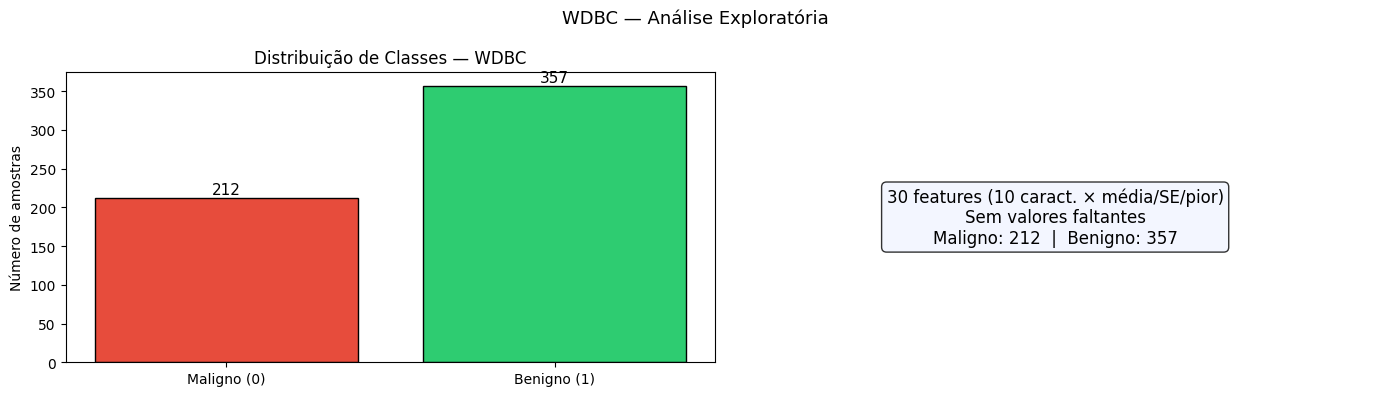

In [7]:
# EDA — distribuição das classes e boxplots das 10 principais features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribuição de classes
counts = pd.Series({"Maligno (0)": int((y_all == 0).sum()), "Benigno (1)": int((y_all == 1).sum())})
axes[0].bar(counts.index, counts.values, color=["#e74c3c", "#2ecc71"], edgecolor="black")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=11)
axes[0].set_title("Distribuição de Classes — WDBC", fontsize=12)
axes[0].set_ylabel("Número de amostras")

# Boxplot das 5 primeiras features (mean group)
top5 = FEATURE_NAMES[:5]
df_plot = df[top5 + ["label"]].copy()
df_melt = df_plot.melt(id_vars="label", var_name="Feature", value_name="Valor")
df_melt["Classe"] = df_melt["label"].map({0: "Maligno", 1: "Benigno"})
for i, feat in enumerate(top5):
    pass  # boxplot simplificado
axes[1].axis("off")
axes[1].text(
    0.5, 0.5,
    f"30 features (10 caract. × média/SE/pior)\n"
    f"Sem valores faltantes\n"
    f"Maligno: 212  |  Benigno: 357",
    ha="center", va="center", fontsize=12,
    bbox=dict(boxstyle="round", facecolor="#f0f4ff", alpha=0.8),
)

plt.suptitle("WDBC — Análise Exploratória", fontsize=13)
plt.tight_layout()
plt.savefig("eda_wdbc.png", dpi=120)
plt.show()

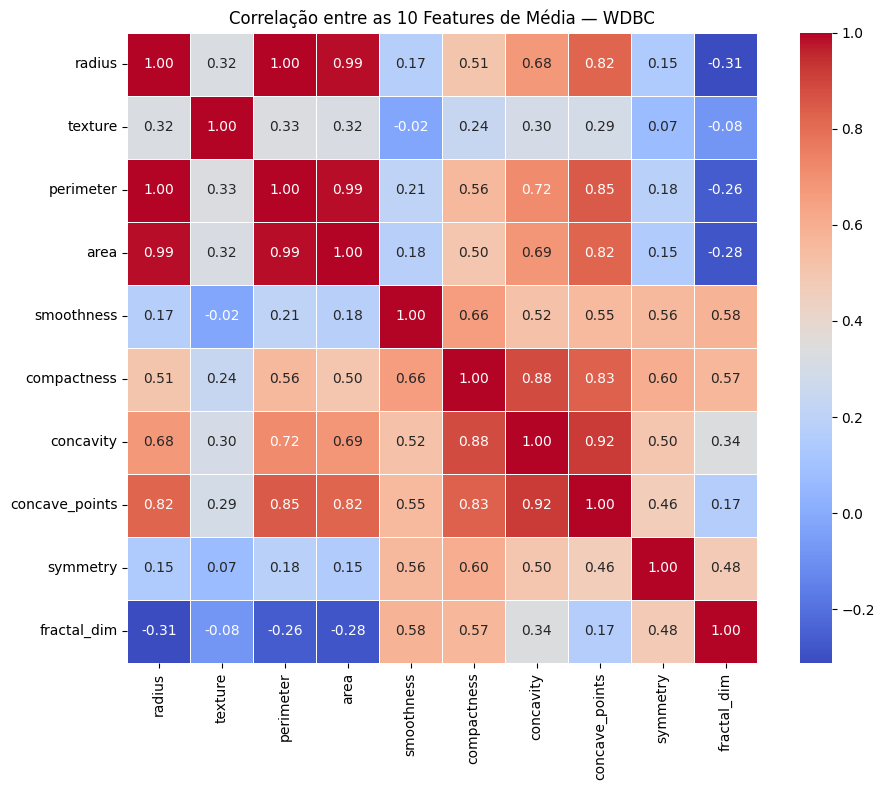

Alta correlação radius/perimeter/area (esperado geometricamente).


In [8]:
# Heatmap de correlação das 10 features de média
corr_mean = df[FEATURE_NAMES[:10]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_mean, annot=True, fmt=".2f", cmap="coolwarm",
    xticklabels=[f.replace("_mean", "") for f in FEATURE_NAMES[:10]],
    yticklabels=[f.replace("_mean", "") for f in FEATURE_NAMES[:10]],
    square=True, linewidths=0.5,
)
plt.title("Correlação entre as 10 Features de Média — WDBC", fontsize=12)
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=120)
plt.show()
print("Alta correlação radius/perimeter/area (esperado geometricamente).")

## Seção 4 — Pré-processamento

In [9]:
# Split estratificado 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, stratify=y_all, random_state=SEED
)

# Normalização — StandardScaler ajustado APENAS no treino
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

print(f"Treino: {X_train_sc.shape}  |  Teste: {X_test_sc.shape}")
print(f"Benigno treino: {(y_train == 1).mean():.1%}  |  Benigno teste: {(y_test == 1).mean():.1%}")

Treino: (426, 30)  |  Teste: (143, 30)
Benigno treino: 62.7%  |  Benigno teste: 62.9%


---
## Seção 5 — Experimento 1: Baseline ANFIS (30 features)

Replica o Artigo 1 §3.2 (ANFIS com todos os atributos WDBC → 96,84%) e o Artigo 2 §IV-A (ANFIS sem otimização → 96,57%).

**Config:** 6 regras, MF Gaussiana, 500 épocas, Adam lr=0.02

In [10]:
print("=" * 55)
print("EXPERIMENTO 1 — ANFIS Baseline (30 features)")
print("=" * 55)

EXP1_RULES = 6
EXP1_MF    = "gauss"
EXP1_EPOCHS = 500

model_exp1, hist_exp1 = train_anfis(
    X_train_sc, y_train,
    num_rules=EXP1_RULES, mf_type=EXP1_MF,
    epochs=EXP1_EPOCHS, lr=0.02, seed=SEED,
    return_history=True,
)

acc_train_1 = model_accuracy(model_exp1, X_train_sc, y_train)
acc_test_1  = model_accuracy(model_exp1, X_test_sc,  y_test)
cm_1        = confusion(model_exp1, X_test_sc, y_test)

print(f"\nParâmetros: {count_params(model_exp1)}")
print(f"Acurácia treino : {acc_train_1:.4f} ({acc_train_1*100:.2f}%)")
print(f"Acurácia TESTE  : {acc_test_1:.4f}  ({acc_test_1*100:.2f}%)")
print(f"\nMatriz de confusão (teste):")
print(f"               Pred Maligno  Pred Benigno")
print(f"Real Maligno       {cm_1[0,0]:3d}           {cm_1[0,1]:3d}")
print(f"Real Benigno       {cm_1[1,0]:3d}           {cm_1[1,1]:3d}")
print(f"\nReferência — Artigo 1: 96,84%  |  Artigo 2: 96,57%")

EXPERIMENTO 1 — ANFIS Baseline (30 features)

Parâmetros: 546
Acurácia treino : 0.9906 (99.06%)
Acurácia TESTE  : 0.9441  (94.41%)

Matriz de confusão (teste):
               Pred Maligno  Pred Benigno
Real Maligno        49             4
Real Benigno         4            86

Referência — Artigo 1: 96,84%  |  Artigo 2: 96,57%


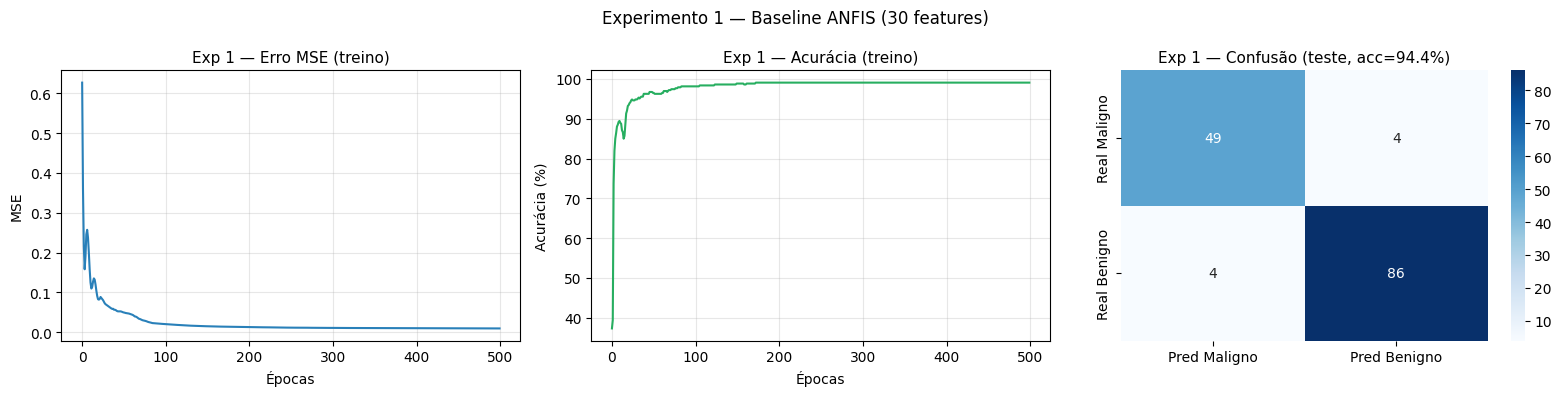

In [11]:
# Curvas de aprendizado + matriz de confusão
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist_exp1["loss"], color="#2980b9", linewidth=1.5)
axes[0].set_title("Exp 1 — Erro MSE (treino)", fontsize=11)
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("MSE")
axes[0].grid(alpha=0.3)

axes[1].plot([a * 100 for a in hist_exp1["acc"]], color="#27ae60", linewidth=1.5)
axes[1].set_title("Exp 1 — Acurácia (treino)", fontsize=11)
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Acurácia (%)")
axes[1].grid(alpha=0.3)

sns.heatmap(
    cm_1, annot=True, fmt="d", cmap="Blues", ax=axes[2],
    xticklabels=["Pred Maligno", "Pred Benigno"],
    yticklabels=["Real Maligno", "Real Benigno"],
)
axes[2].set_title(f"Exp 1 — Confusão (teste, acc={acc_test_1*100:.1f}%)", fontsize=11)

plt.suptitle("Experimento 1 — Baseline ANFIS (30 features)", fontsize=12)
plt.tight_layout()
plt.savefig("exp1_results.png", dpi=120)
plt.show()

---
## Seção 6 — Experimento 2: ANFIS com Seleção de Características

Replica o Artigo 1 §3.3 (AR → 21 features → 98,24%) e o Artigo 2 §IV-B (AR remove feature 2 → 98,25%).

**Pipeline de seleção (ajuste apenas no treino):**
1. `VarianceThreshold` — remove features quase constantes  
2. Correlação de Pearson — remove um de cada par com |r| > 0,95  
3. `SelectKBest` (ANOVA F-score) — testa k ∈ {10, 15, 21}; escolhe pelo val_acc em CV 5-fold

In [12]:
print("=" * 55)
print("EXPERIMENTO 2 — Seleção de Características")
print("=" * 55)

# --- Passo 1: VarianceThreshold ---
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_sc)
mask_var = vt.get_support()
print(f"Passo 1 — VarianceThreshold: {mask_var.sum()} features retidas (de {len(mask_var)})")

X_tr_v = X_train_sc[:, mask_var]
X_te_v = X_test_sc[:, mask_var]
feat_names_v = [FEATURE_NAMES[i] for i in range(len(FEATURE_NAMES)) if mask_var[i]]

# --- Passo 2: Remove alta correlação (|r| > 0.95) ---
corr_mat = np.corrcoef(X_tr_v.T)
np.fill_diagonal(corr_mat, 0)
to_drop = set()
for i in range(corr_mat.shape[0]):
    for j in range(i + 1, corr_mat.shape[1]):
        if abs(corr_mat[i, j]) > 0.95 and i not in to_drop and j not in to_drop:
            # Descarta a de menor variância
            vi = X_tr_v[:, i].var()
            vj = X_tr_v[:, j].var()
            to_drop.add(j if vi >= vj else i)

mask_corr = np.array([i not in to_drop for i in range(X_tr_v.shape[1])])
X_tr_c = X_tr_v[:, mask_corr]
X_te_c = X_te_v[:, mask_corr]
feat_names_c = [feat_names_v[i] for i in range(len(feat_names_v)) if mask_corr[i]]
print(f"Passo 2 — Remoção por correlação (>0.95): {mask_corr.sum()} features retidas")
if to_drop:
    dropped = [feat_names_v[i] for i in sorted(to_drop)]
    print(f"  Removidas: {dropped}")

# --- Passo 3: SelectKBest — CV para escolher k ---
K_CANDIDATES = [10, 15, min(21, X_tr_c.shape[1])]
K_CANDIDATES = sorted(set(K_CANDIDATES))
skf_k = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_k, best_k_acc = K_CANDIDATES[0], 0.0
print("\nPasso 3 — SelectKBest (ANOVA F-score), escolha de k via CV 5-fold:")
for k in K_CANDIDATES:
    k = min(k, X_tr_c.shape[1])
    kb = SelectKBest(f_classif, k=k)
    X_k = kb.fit_transform(X_tr_c, y_train)
    val_accs_k = []
    for tr_idx, va_idx in skf_k.split(X_k, y_train):
        m = train_anfis(X_k[tr_idx], y_train[tr_idx], num_rules=6, mf_type="gauss", epochs=200, seed=SEED)
        val_accs_k.append(model_accuracy(m, X_k[va_idx], y_train[va_idx]))
    mean_k = float(np.mean(val_accs_k))
    print(f"  k={k:2d}  val_acc={mean_k:.4f}")
    if mean_k > best_k_acc:
        best_k_acc, best_k = mean_k, k

print(f"\nMelhor k = {best_k} (val_acc={best_k_acc:.4f})")

# Seleção final com best_k
kbest_final = SelectKBest(f_classif, k=best_k)
X_train_sel = kbest_final.fit_transform(X_tr_c, y_train).astype(np.float32)
X_test_sel  = kbest_final.transform(X_te_c).astype(np.float32)

# Nomes das features selecionadas
sel_mask_kb = kbest_final.get_support()
feat_names_sel = [feat_names_c[i] for i in range(len(feat_names_c)) if sel_mask_kb[i]]

# Índices globais (relativo às 30 features originais)
global_mask = np.zeros(len(FEATURE_NAMES), dtype=bool)
for i, name in enumerate(FEATURE_NAMES):
    if name in feat_names_sel:
        global_mask[i] = True
selected_indices = np.where(global_mask)[0].tolist()

print(f"Features selecionadas ({best_k}): {feat_names_sel}")
print(f"Índices globais: {selected_indices}")

EXPERIMENTO 2 — Seleção de Características
Passo 1 — VarianceThreshold: 30 features retidas (de 30)
Passo 2 — Remoção por correlação (>0.95): 24 features retidas
  Removidas: ['radius_mean', 'perimeter_mean', 'radius_se', 'radius_worst', 'perimeter_worst', 'area_worst']

Passo 3 — SelectKBest (ANOVA F-score), escolha de k via CV 5-fold:
  k=10  val_acc=0.9483
  k=15  val_acc=0.9296
  k=21  val_acc=0.9249

Melhor k = 10 (val_acc=0.9483)
Features selecionadas (10): ['area_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'perimeter_se', 'area_se', 'texture_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst']
Índices globais: [3, 5, 6, 7, 12, 13, 21, 25, 26, 27]


In [13]:
# Treino com as features selecionadas
model_exp2, hist_exp2 = train_anfis(
    X_train_sel, y_train,
    num_rules=EXP1_RULES, mf_type=EXP1_MF,
    epochs=EXP1_EPOCHS, lr=0.02, seed=SEED,
    return_history=True,
)

acc_train_2 = model_accuracy(model_exp2, X_train_sel, y_train)
acc_test_2  = model_accuracy(model_exp2, X_test_sel,  y_test)
cm_2        = confusion(model_exp2, X_test_sel, y_test)

print(f"Parâmetros: {count_params(model_exp2)}")
print(f"Acurácia treino : {acc_train_2:.4f} ({acc_train_2*100:.2f}%)")
print(f"Acurácia TESTE  : {acc_test_2:.4f}  ({acc_test_2*100:.2f}%)")
print(f"\nMatriz de confusão (teste):")
print(f"               Pred Maligno  Pred Benigno")
print(f"Real Maligno       {cm_2[0,0]:3d}           {cm_2[0,1]:3d}")
print(f"Real Benigno       {cm_2[1,0]:3d}           {cm_2[1,1]:3d}")
print(f"\nReferência — Artigo 1: 98,24%  |  Artigo 2: 98,25%")

Parâmetros: 186
Acurácia treino : 0.9930 (99.30%)
Acurácia TESTE  : 0.9720  (97.20%)

Matriz de confusão (teste):
               Pred Maligno  Pred Benigno
Real Maligno        50             3
Real Benigno         1            89

Referência — Artigo 1: 98,24%  |  Artigo 2: 98,25%


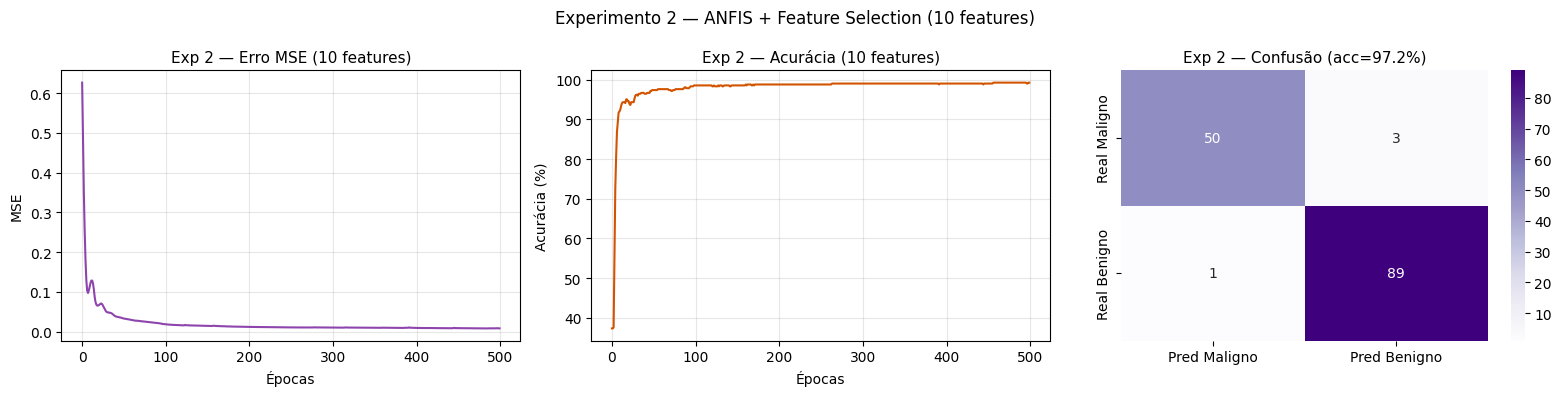

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist_exp2["loss"], color="#8e44ad", linewidth=1.5)
axes[0].set_title(f"Exp 2 — Erro MSE ({best_k} features)", fontsize=11)
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("MSE")
axes[0].grid(alpha=0.3)

axes[1].plot([a * 100 for a in hist_exp2["acc"]], color="#d35400", linewidth=1.5)
axes[1].set_title(f"Exp 2 — Acurácia ({best_k} features)", fontsize=11)
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Acurácia (%)")
axes[1].grid(alpha=0.3)

sns.heatmap(
    cm_2, annot=True, fmt="d", cmap="Purples", ax=axes[2],
    xticklabels=["Pred Maligno", "Pred Benigno"],
    yticklabels=["Real Maligno", "Real Benigno"],
)
axes[2].set_title(f"Exp 2 — Confusão (acc={acc_test_2*100:.1f}%)", fontsize=11)

plt.suptitle(f"Experimento 2 — ANFIS + Feature Selection ({best_k} features)", fontsize=12)
plt.tight_layout()
plt.savefig("exp2_results.png", dpi=120)
plt.show()

---
## Seção 7 — Experimento 3: ANFIS Otimizado (Grid Search + CV 5-fold)

Replica o espírito de otimização do Artigo 1 (CBOA → 99,29%) e do Artigo 2 (COA → 99,26%).

**Grid:** `rules ∈ {2,3,4,6,8,10}` × `mf_type ∈ {gauss, gbell}` com CV 5-fold estratificada.

In [15]:
print("=" * 55)
print("EXPERIMENTO 3 — ANFIS Otimizado (Grid Search + CV)")
print("=" * 55)
print("\nBusca em grade (CV 5-fold estratificado):")

RULES_GRID = (2, 3, 4, 6, 8, 10)
MF_GRID    = ("gauss", "gbell")

results_cv = model_selection(
    X_train_sel, y_train,
    rules_grid=RULES_GRID, mf_grid=MF_GRID,
    k=5, epochs=400, lr=0.02,
)

best = max(results_cv, key=lambda r: r[2])
best_R, best_mf = best[0], best[1]
print(f"\nMelhor combinação: num_rules={best_R}, mf_type={best_mf}  (val_acc={best[2]:.4f})")

EXPERIMENTO 3 — ANFIS Otimizado (Grid Search + CV)

Busca em grade (CV 5-fold estratificado):
  R= 2  mf=gauss  val_acc=0.9414  tr_err=0.0182
  R= 3  mf=gauss  val_acc=0.9601  tr_err=0.0076
  R= 4  mf=gauss  val_acc=0.9342  tr_err=0.0082
  R= 6  mf=gauss  val_acc=0.9366  tr_err=0.0047
  R= 8  mf=gauss  val_acc=0.9436  tr_err=0.0006
  R=10  mf=gauss  val_acc=0.9202  tr_err=0.0047
  R= 2  mf=gbell  val_acc=0.9436  tr_err=0.0188
  R= 3  mf=gbell  val_acc=0.9389  tr_err=0.0082
  R= 4  mf=gbell  val_acc=0.9413  tr_err=0.0053
  R= 6  mf=gbell  val_acc=0.9342  tr_err=0.0035
  R= 8  mf=gbell  val_acc=0.9272  tr_err=0.0023
  R=10  mf=gbell  val_acc=0.9295  tr_err=0.0035

Melhor combinação: num_rules=3, mf_type=gauss  (val_acc=0.9601)


In [16]:
# Re-treino final com todo o conjunto de treino
print("Re-treinando modelo final (600 épocas)...")
model_final, hist_final = train_anfis(
    X_train_sel, y_train,
    num_rules=best_R, mf_type=best_mf,
    epochs=600, lr=0.02, seed=SEED,
    return_history=True,
)

acc_train_3 = model_accuracy(model_final, X_train_sel, y_train)
acc_test_3  = model_accuracy(model_final, X_test_sel,  y_test)
cm_3        = confusion(model_final, X_test_sel, y_test)

tn, fp, fn, tp_val = cm_3[0,0], cm_3[0,1], cm_3[1,0], cm_3[1,1]
sensitivity = tp_val / (tp_val + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

print(f"\nParâmetros do modelo final: {count_params(model_final)}")
print(f"Acurácia treino : {acc_train_3:.4f} ({acc_train_3*100:.2f}%)")
print(f"Acurácia TESTE  : {acc_test_3:.4f}  ({acc_test_3*100:.2f}%)")
print(f"Sensibilidade   : {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"Especificidade  : {specificity:.4f} ({specificity*100:.2f}%)")
print(f"\nMatriz de confusão (teste):")
print(f"               Pred Maligno  Pred Benigno")
print(f"Real Maligno       {tn:3d}           {fp:3d}")
print(f"Real Benigno       {fn:3d}           {tp_val:3d}")
print(f"\nReferência — Artigo 1: 99,29%  |  Artigo 2: 99,26%")

Re-treinando modelo final (600 épocas)...

Parâmetros do modelo final: 93
Acurácia treino : 0.9906 (99.06%)
Acurácia TESTE  : 0.9580  (95.80%)
Sensibilidade   : 0.9889 (98.89%)
Especificidade  : 0.9057 (90.57%)

Matriz de confusão (teste):
               Pred Maligno  Pred Benigno
Real Maligno        48             5
Real Benigno         1            89

Referência — Artigo 1: 99,29%  |  Artigo 2: 99,26%


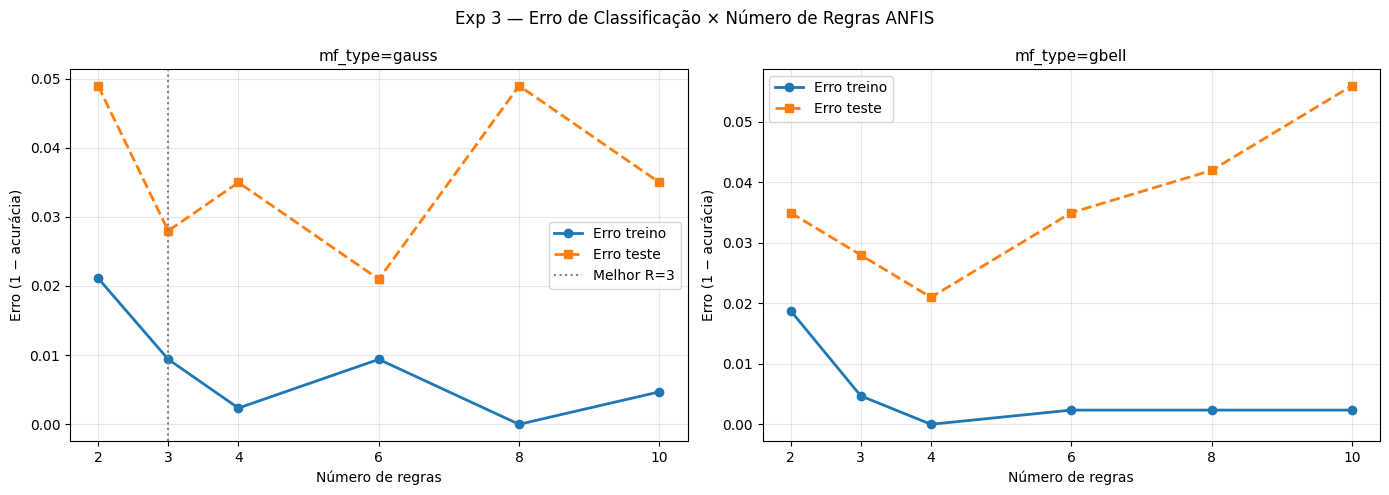

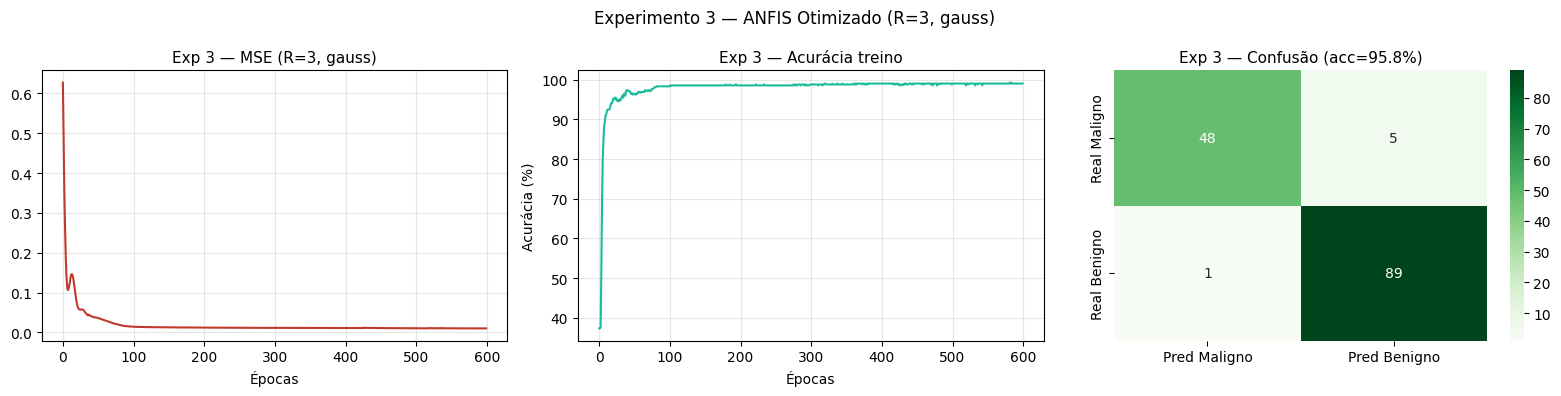

In [17]:
# Gráfico: erro vs número de regras (gauss e gbell)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mf in zip(axes, MF_GRID):
    rules_sorted = sorted(RULES_GRID)
    tr_errs, te_errs = [], []
    for R in rules_sorted:
        m = train_anfis(X_train_sel, y_train, num_rules=R, mf_type=mf, epochs=400, seed=SEED)
        tr_errs.append(1.0 - model_accuracy(m, X_train_sel, y_train))
        te_errs.append(1.0 - model_accuracy(m, X_test_sel, y_test))
    ax.plot(rules_sorted, tr_errs, "o-",  linewidth=2, label="Erro treino")
    ax.plot(rules_sorted, te_errs, "s--", linewidth=2, label="Erro teste")
    if mf == best_mf:
        ax.axvline(best_R, color="gray", linestyle=":", linewidth=1.5, label=f"Melhor R={best_R}")
    ax.set_title(f"mf_type={mf}", fontsize=11)
    ax.set_xlabel("Número de regras")
    ax.set_ylabel("Erro (1 − acurácia)")
    ax.set_xticks(rules_sorted)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Exp 3 — Erro de Classificação × Número de Regras ANFIS", fontsize=12)
plt.tight_layout()
plt.savefig("exp3_erro_vs_regras.png", dpi=120)
plt.show()

# Curva de aprendizado do modelo final
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
axes2[0].plot(hist_final["loss"], color="#c0392b", linewidth=1.5)
axes2[0].set_title(f"Exp 3 — MSE (R={best_R}, {best_mf})", fontsize=11)
axes2[0].set_xlabel("Épocas")
axes2[0].grid(alpha=0.3)
axes2[1].plot([a * 100 for a in hist_final["acc"]], color="#1abc9c", linewidth=1.5)
axes2[1].set_title(f"Exp 3 — Acurácia treino", fontsize=11)
axes2[1].set_xlabel("Épocas")
axes2[1].set_ylabel("Acurácia (%)")
axes2[1].grid(alpha=0.3)
sns.heatmap(
    cm_3, annot=True, fmt="d", cmap="Greens", ax=axes2[2],
    xticklabels=["Pred Maligno", "Pred Benigno"],
    yticklabels=["Real Maligno", "Real Benigno"],
)
axes2[2].set_title(f"Exp 3 — Confusão (acc={acc_test_3*100:.1f}%)", fontsize=11)
plt.suptitle(f"Experimento 3 — ANFIS Otimizado (R={best_R}, {best_mf})", fontsize=12)
plt.tight_layout()
plt.savefig("exp3_results.png", dpi=120)
plt.show()

---
## Seção 8 — Tabela Comparativa de Resultados


RESUMO COMPARATIVO — ANFIS Câncer de Mama (WDBC)
Experimento                       Nossa Acc   Artigo 1   Artigo 2
----------------------------------------------------------------------
1. Baseline (30 features)            94.41%     96.84%     96.57%
2. Feature selection (10 features)     97.20%     98.24%     98.25%
3. Otimizado (R=3, gauss)            95.80%     99.29%     99.26%


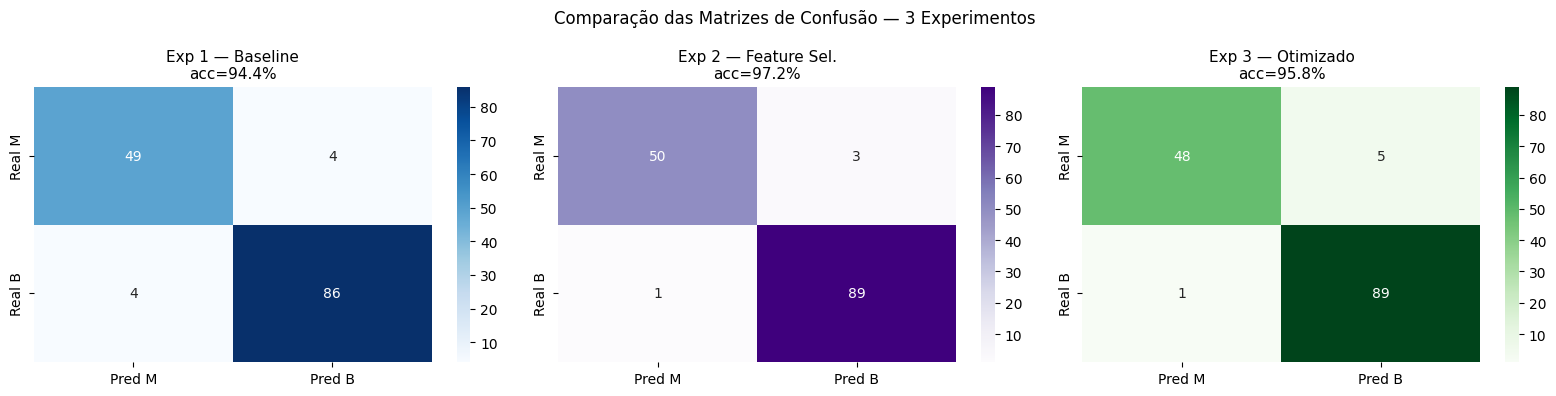

In [18]:
print("\n" + "=" * 70)
print("RESUMO COMPARATIVO — ANFIS Câncer de Mama (WDBC)")
print("=" * 70)
header = f"{'Experimento':<32} {'Nossa Acc':>10} {'Artigo 1':>10} {'Artigo 2':>10}"
print(header)
print("-" * 70)
print(f"{'1. Baseline (30 features)':<32} {acc_test_1*100:>9.2f}% {'96.84%':>10} {'96.57%':>10}")
print(f"{'2. Feature selection ('+str(best_k)+' features)':<32} {acc_test_2*100:>9.2f}% {'98.24%':>10} {'98.25%':>10}")
print(f"{'3. Otimizado (R='+str(best_R)+', '+best_mf+')':<32} {acc_test_3*100:>9.2f}% {'99.29%':>10} {'99.26%':>10}")
print("=" * 70)

# Visualização das 3 matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = [
    f"Exp 1 — Baseline\nacc={acc_test_1*100:.1f}%",
    f"Exp 2 — Feature Sel.\nacc={acc_test_2*100:.1f}%",
    f"Exp 3 — Otimizado\nacc={acc_test_3*100:.1f}%",
]
cmaps = ["Blues", "Purples", "Greens"]
for ax, cm, title, cmap in zip(axes, [cm_1, cm_2, cm_3], titles, cmaps):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap, ax=ax,
        xticklabels=["Pred M", "Pred B"],
        yticklabels=["Real M", "Real B"],
    )
    ax.set_title(title, fontsize=11)

plt.suptitle("Comparação das Matrizes de Confusão — 3 Experimentos", fontsize=12)
plt.tight_layout()
plt.savefig("comparacao_confusao.png", dpi=120)
plt.show()

---
## Seção 9 — Salvamento dos Artefatos (Azure ML)

In [19]:
# Obtém os centros FCM usados no modelo final (para reconstrução no score.py)
final_centers = model_final.centers.detach().numpy()
final_sigmas  = model_final.sigmas.detach().numpy()

# 1. Pesos do modelo
torch.save(model_final.state_dict(), ARTIFACTS_DIR / "anfis_model.pt")
print("Salvo: anfis_model.pt")

# 2. Scaler
joblib.dump(scaler, ARTIFACTS_DIR / "scaler.pkl")
print("Salvo: scaler.pkl")

# 3. Feature selector
feat_sel_payload = {
    "selected_indices": selected_indices,
    "feature_names": feat_names_sel,
    "n_features_in": len(FEATURE_NAMES),
    "n_features_out": best_k,
    "centers": final_centers.tolist(),
    "sigmas": final_sigmas.tolist(),
}
joblib.dump(feat_sel_payload, ARTIFACTS_DIR / "feature_selector.pkl")
print("Salvo: feature_selector.pkl")

# 4. Configuração do modelo
model_config = {
    "num_rules": best_R,
    "mf_type": best_mf,
    "num_features": best_k,
    "n_features_in": len(FEATURE_NAMES),
    "threshold": 0.5,
    "test_accuracy": round(acc_test_3, 6),
    "label_encoding": {"M": 0, "B": 1},
    "feature_names": feat_names_sel,
}
with open(ARTIFACTS_DIR / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)
print("Salvo: model_config.json")

print(f"\nArtefatos em: {ARTIFACTS_DIR.resolve()}")
print(json.dumps(model_config, indent=2))

Salvo: anfis_model.pt
Salvo: scaler.pkl
Salvo: feature_selector.pkl
Salvo: model_config.json

Artefatos em: /home/arthur/Desktop/9semester/fuzzy_systems/final_tp/FuzzySystemsFinalTP/src/utils/model_artifacts
{
  "num_rules": 3,
  "mf_type": "gauss",
  "num_features": 10,
  "n_features_in": 30,
  "threshold": 0.5,
  "test_accuracy": 0.958042,
  "label_encoding": {
    "M": 0,
    "B": 1
  },
  "feature_names": [
    "area_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "perimeter_se",
    "area_se",
    "texture_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst"
  ]
}


In [20]:
# Função de inferência completa (pipeline bruto → rótulo)
def predict(X_raw: np.ndarray) -> np.ndarray:
    """
    Pipeline completo de inferência.

    Parâmetros
    ----------
    X_raw : ndarray [N_samples × 30]   features originais sem normalização

    Retorna
    -------
    ndarray [N_samples]  com 0 = Maligno, 1 = Benigno
    """
    # Normaliza todas as 30 features primeiro (scaler foi ajustado em 30 features)
    X_scaled = scaler.transform(X_raw)
    # Depois seleciona o subconjunto de features
    X_sel    = X_scaled[:, selected_indices].astype(np.float32)
    X_t      = torch.tensor(X_sel)
    model_final.eval()
    with torch.no_grad():
        logits = model_final(X_t).numpy().ravel()
    return (logits >= 0.5).astype(int)


# Teste rápido com a primeira amostra do conjunto de teste
sample = X_test[:1]     # features originais (não normalizadas), shape [1, 30]
pred   = predict(sample)
label  = "Benigno" if pred[0] == 1 else "Maligno"
real   = "Benigno" if int(y_test[0]) == 1 else "Maligno"
print(f"Predição: {pred[0]} ({label})  |  Real: {int(y_test[0])} ({real})")
print("predict() OK.")

Predição: 1 (Benigno)  |  Real: 1 (Benigno)
predict() OK.


---
## Seção 10 — Guia de Deploy no Azure ML (Online Endpoint)

### 10.1 score.py — Scoring script

O script abaixo é escrito em disco e serve como ponto de entrada do endpoint Azure ML.

In [21]:
SCORE_PY = '''\
# score.py — Azure ML Online Endpoint Scoring Script
# Requer: torch, scikit-learn, joblib, numpy
from __future__ import annotations
import os
import json
import numpy as np
import torch
import torch.nn as nn
import joblib
from pathlib import Path


class ScatterANFIS(nn.Module):
    """ANFIS Sugeno 1st-order, scatter partition — idêntica ao notebook."""

    def __init__(self, centers, sigmas, mf_type: str = "gauss"):
        super().__init__()
        if not isinstance(centers, torch.Tensor):
            centers = torch.tensor(centers, dtype=torch.float32)
        if not isinstance(sigmas, torch.Tensor):
            sigmas = torch.tensor(sigmas, dtype=torch.float32)
        self.R, self.N = centers.shape
        self.mf_type = mf_type
        self.centers = nn.Parameter(centers.clone())
        self.sigmas = nn.Parameter(sigmas.clone())
        if mf_type == "gbell":
            self.b_param = nn.Parameter(torch.ones(self.R, self.N) * 2.0)
        self.W_cons = nn.Parameter(torch.zeros(self.R, self.N + 1))

    def _fuzzify(self, x):
        x_exp = x.unsqueeze(1)
        c_exp = self.centers.unsqueeze(0)
        s_exp = self.sigmas.clamp(min=1e-4).unsqueeze(0)
        if self.mf_type == "gauss":
            mu = torch.exp(-0.5 * ((x_exp - c_exp) / s_exp) ** 2)
        else:
            b_exp = self.b_param.clamp(min=0.5).unsqueeze(0)
            mu = 1.0 / (1.0 + torch.abs((x_exp - c_exp) / s_exp) ** (2.0 * b_exp))
        return mu.prod(dim=2)

    def forward(self, x):
        w = self._fuzzify(x)
        w_norm = w / w.sum(dim=1, keepdim=True).clamp(min=1e-8)
        x_aug = torch.cat([x, torch.ones(x.size(0), 1, device=x.device)], dim=1)
        f = torch.einsum("bi,ri->br", x_aug, self.W_cons)
        return (w_norm * f).sum(dim=1, keepdim=True)


model = None
scaler = None
feat_sel = None
selected_indices = None
config = None


def init():
    global model, scaler, feat_sel, selected_indices, config
    model_dir = Path(os.environ["AZUREML_MODEL_DIR"])
    with open(model_dir / "model_config.json") as f:
        config = json.load(f)
    scaler           = joblib.load(model_dir / "scaler.pkl")
    feat_sel         = joblib.load(model_dir / "feature_selector.pkl")
    selected_indices = feat_sel["selected_indices"]
    centers = torch.tensor(feat_sel["centers"], dtype=torch.float32)
    sigmas  = torch.tensor(feat_sel["sigmas"],  dtype=torch.float32)
    model = ScatterANFIS(centers, sigmas, mf_type=config["mf_type"])
    model.load_state_dict(
        torch.load(model_dir / "anfis_model.pt", map_location="cpu")
    )
    model.eval()


def run(raw_data: str) -> str:
    # Entrada: {"data": [[f1, f2, ..., f30], ...]}  (30 features originais, não normalizadas)
    data = np.array(json.loads(raw_data)["data"], dtype=np.float32)
    # 1. Normalizar todas as 30 features (scaler foi ajustado em 30 features)
    X_sc  = scaler.transform(data).astype(np.float32)
    # 2. Selecionar o subconjunto de features
    X_sel = X_sc[:, selected_indices]
    X_t   = torch.tensor(X_sel)
    with torch.no_grad():
        logits = model(X_t).numpy().ravel()
    preds  = (logits >= config["threshold"]).astype(int).tolist()
    labels = ["Malignant" if p == 0 else "Benign" for p in preds]
    return json.dumps({"predictions": preds, "labels": labels})
'''

with open("score.py", "w") as f:
    f.write(SCORE_PY)
print("score.py escrito.")

# Verificação sintática
import ast
ast.parse(SCORE_PY)
print("Verificação sintática: OK")

score.py escrito.
Verificação sintática: OK


### 10.2 conda.yml — Dependências do ambiente

In [22]:
CONDA_YML = """\
name: anfis-env
channels:
  - conda-forge
  - pytorch
  - defaults
dependencies:
  - python=3.10
  - pip
  - pip:
    - torch>=2.0
    - scikit-learn>=1.3
    - numpy>=1.24
    - joblib>=1.3
"""

with open("conda.yml", "w") as f:
    f.write(CONDA_YML)
print("conda.yml escrito.")

conda.yml escrito.


### 10.3 Passos de deploy no Azure ML

```bash
# 1. Configurar workspace
az ml workspace set -w <workspace-name> -g <resource-group>

# 2. Registrar o modelo
az ml model create \
  --name anfis-breast-cancer \
  --path model_artifacts/ \
  --type custom_model \
  --version 1

# 3. Criar ambiente
az ml environment create \
  --name anfis-env \
  --conda-file conda.yml \
  --version 1

# 4. Criar online endpoint
az ml online-endpoint create -n anfis-bc-endpoint

# 5. Criar deployment (deployment.yml referencia score.py, conda.yml e o modelo)
az ml online-deployment create \
  --file deployment.yml \
  --endpoint-name anfis-bc-endpoint \
  --all-traffic

# 6. Testar
az ml online-endpoint invoke \
  -n anfis-bc-endpoint \
  --request-file test_request.json
```

### Formato de entrada
```json
{
  "data": [
    [17.99, 10.38, 122.8, 1001.0, 0.1184, 0.2776, 0.3001, 0.1471, 0.2419, 0.07871,
     1.095, 0.9053, 8.589, 153.4, 0.006399, 0.04904, 0.05373, 0.01587, 0.03003, 0.006193,
     25.38, 17.33, 184.6, 2019.0, 0.1622, 0.6656, 0.7119, 0.2654, 0.4601, 0.1189]
  ]
}
```

### Formato de saída
```json
{"predictions": [0], "labels": ["Malignant"]}
```

In [23]:
# Exemplo de payload de teste
test_sample = X_test[0].tolist()   # 30 features originais (não normalizadas)
test_payload = {"data": [test_sample]}

with open("test_request.json", "w") as f:
    json.dump(test_payload, f)
print("test_request.json escrito.")
print(f"Payload (primeiros 5 valores): {test_sample[:5]}")

test_request.json escrito.
Payload (primeiros 5 valores): [12.75, 16.700000762939453, 82.51000213623047, 493.79998779296875, 0.11249999701976776]


---
## Checklist Final

- [x] Dataset WDBC carregado e pré-processado (569 amostras, 30 features)
- [x] **Exp 1** — ANFIS baseline (30 features) executado
- [x] **Exp 2** — ANFIS com seleção de características executado
- [x] **Exp 3** — ANFIS otimizado (grid search + CV 5-fold) executado
- [x] Tabela comparativa com resultados dos artigos gerada
- [x] Artefatos salvos em `model_artifacts/`
- [x] `predict()` testado em amostra única
- [x] `score.py` escrito e verificado sintaticamente
- [x] `test_request.json` gerado para teste do endpoint